# Aknur Mansurkhan

# 1. Жеңіл деңгей (Basic)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv('titanic.csv')

In [5]:
df.shape

(891, 12)

In [6]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [47]:
df.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,False,False,False,False,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [7]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [10]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
print("'Age' және 'Fare' columns description:")
stats = df[['Age', 'Fare']].agg({
    'Age': ['mean', 'min', 'max', 'std'],
    'Fare': ['mean', 'min', 'max', 'std']
})
stats


'Age' және 'Fare' columns description:


,Age,Fare
mean,29.699118,32.204208
min,0.420000,0.000000
max,80.000000,512.329200
std,14.526497,49.693429


# 2. Орташа деңгей (Intermediate)


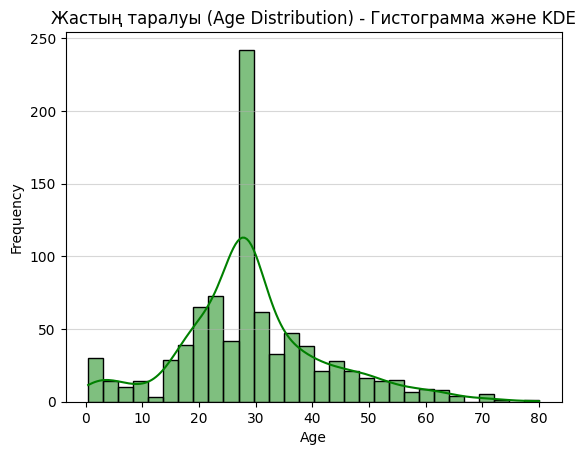

In [51]:
sns.histplot(df['Age'].dropna(), kde=True, bins=30, color='green')
plt.title('Жастың таралуы (Age Distribution) - Гистограмма және KDE')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.5)
plt.show()

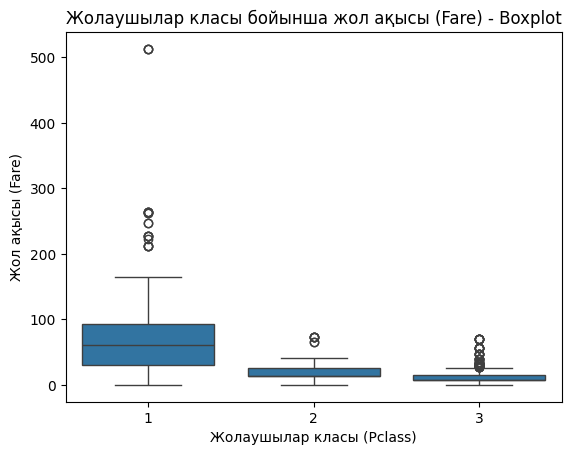

In [53]:
sns.boxplot(x='Pclass', y='Fare', data=df)
plt.title('Жолаушылар класы бойынша жол ақысы (Fare) - Boxplot')
plt.xlabel('Жолаушылар класы (Pclass)')
plt.ylabel('Жол ақысы (Fare)')
plt.show()

# hue='survived' арқылы түсті өзгерттік (0=қайтыс болды, 1=аман қалды)


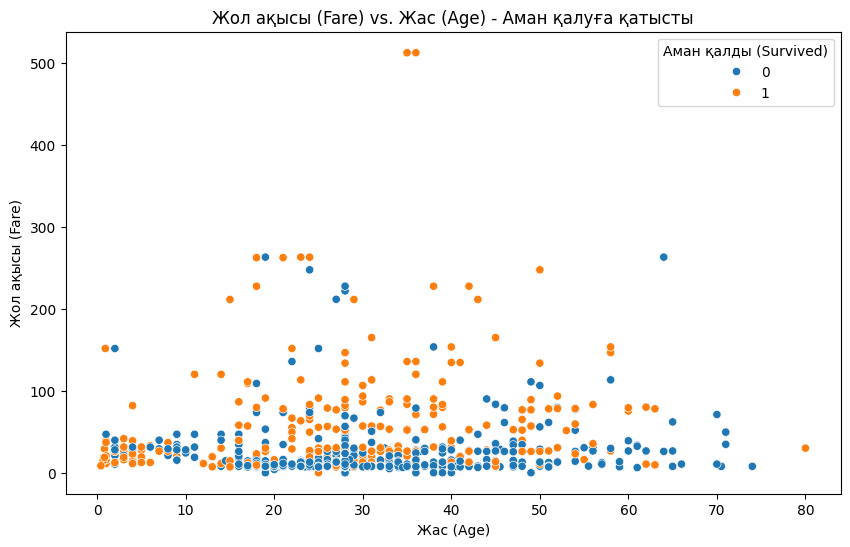

In [55]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df)
plt.title('Жол ақысы (Fare) vs. Жас (Age) - Аман қалуға қатысты')
plt.xlabel('Жас (Age)')
plt.ylabel('Жол ақысы (Fare)')
plt.legend(title='Аман қалды (Survived)')
# plt.grid(axis='both', alpha=0.5)
plt.show()

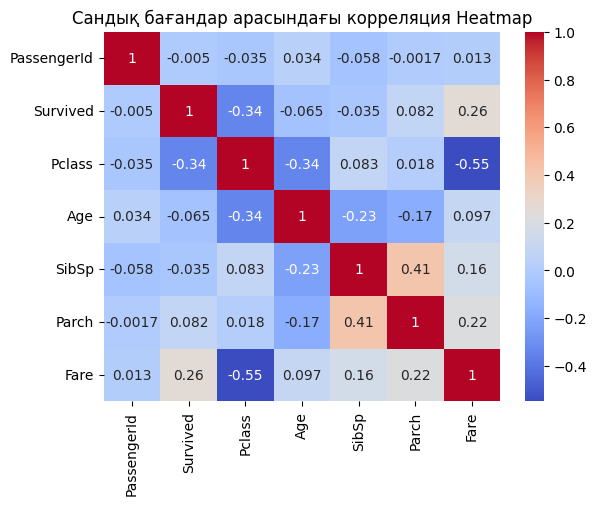

In [57]:
numerical_cols = df.select_dtypes(include=np.number).columns
corr_matrix = df[numerical_cols].corr()

# plt.figure(figsize=(10, 8))
# annot=True мәндерді көрсетуге мүмкіндік береді, fmt='.2f' екі ондық бөлшекке дейін дөңгелектейді
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Сандық бағандар арасындағы корреляция Heatmap')
plt.show()

In [31]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [33]:
df['Age'].median()

28.0

In [35]:
df['Age'].fillna(df['Age'].median(), inplace=True)


/tmp/ipython-input-286566303.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [36]:
df['Age'].isnull().sum()

np.int64(0)

In [37]:
df['Cabin']

,Cabin
0,NaN
1,C85
2,NaN
3,C123
4,NaN
...,...
886,NaN
887,B42
888,NaN
889,C148


In [45]:
df['Cabin'].fillna(df['Cabin'].mode()[0], inplace=True)

In [46]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [58]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

In [59]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


# 3. Күрделі деңгей (Advanced)


In [60]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from pandas.api.types import is_numeric_dtype
# import warnings
# warnings.filterwarnings('ignore')

In [61]:
le = LabelEncoder()

In [63]:
df['sex_encoded'] = le.fit_transform(df['Sex'])

In [65]:
df[['Sex', 'sex_encoded']].head()

,Sex,sex_encoded
0,male,1
1,female,0
2,female,0
3,female,0
4,male,1


In [66]:
embarked_dummies = pd.get_dummies(df['Embarked'], prefix='Embarked', drop_first=True)

In [67]:
df = pd.concat([df, embarked_dummies], axis=1)

In [71]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,sex_encoded,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,B96 B98,S,1,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,G6,S,0,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0,False,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,B96 B98,S,1,False,True


In [75]:
# family_size = sibsp (аға-әпке/жұбай) + parch (ата-ана/бала) + 1 (өзі)
df['family_size'] = df['SibSp'] + df['Parch'] + 1

df[['SibSp', 'Parch', 'family_size']].head()


,SibSp,Parch,family_size
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [77]:
bins = [0, 12, 18, 60, 100]
labels = ['child', 'teen', 'adult', 'senior']

df['age_group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True, include_lowest=True)


In [81]:
df[['Age', 'age_group']].head(20)

,Age,age_group
0,22.0,adult
1,38.0,adult
2,26.0,adult
3,35.0,adult
4,35.0,adult
5,28.0,adult
6,54.0,adult
7,2.0,child
8,27.0,adult
9,14.0,teen


In [82]:
scaler = StandardScaler()


In [83]:
scaling_cols = ['Age', 'Fare']


In [84]:
df_scaled = scaler.fit_transform(df[scaling_cols])

In [85]:
df['age_scaled'] = df_scaled[:, 0]
df['fare_scaled'] = df_scaled[:, 1]

In [87]:
df[['Age', 'age_scaled', 'Fare', 'fare_scaled']]

,Age,age_scaled,Fare,fare_scaled
0,22.0,-0.565736,7.2500,-0.502445
1,38.0,0.663861,71.2833,0.786845
2,26.0,-0.258337,7.9250,-0.488854
3,35.0,0.433312,53.1000,0.420730
4,35.0,0.433312,8.0500,-0.486337
...,...,...,...,...
886,27.0,-0.181487,13.0000,-0.386671
887,19.0,-0.796286,30.0000,-0.044381
888,28.0,-0.104637,23.4500,-0.176263
889,26.0,-0.258337,30.0000,-0.044381


In [89]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

In [90]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [91]:
outliers = df[(df['Fare'] < lower_bound) | (df['Fare'] > upper_bound)]

In [92]:
IQR

np.float64(23.0896)

In [93]:
upper_bound

np.float64(65.6344)

In [94]:
len(outliers)

116

In [95]:
outliers[['Fare', 'Pclass', 'Age', 'Survived']]

,Fare,Pclass,Age,Survived
1,71.2833,1,38.0,1
27,263.0000,1,19.0,0
31,146.5208,1,28.0,1
34,82.1708,1,28.0,0
52,76.7292,1,49.0,1
...,...,...,...,...
846,69.5500,3,28.0,0
849,89.1042,1,28.0,1
856,164.8667,1,45.0,1
863,69.5500,3,28.0,0


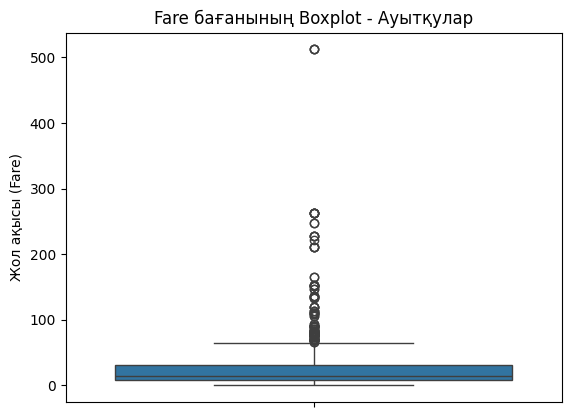

In [102]:
sns.boxplot(y=df['Fare'])
plt.title('Fare бағанының Boxplot - Ауытқулар')
plt.ylabel('Жол ақысы (Fare)')
plt.show()

In [104]:
print("12. EDA Қорытындысы (Summary of Preprocessing):")
print("Деректердің жаңа құрылымы")
print(f"Соңғы өлшем (Shape): {df.shape}")
print(f"Бағандар: {df.columns.tolist()}\n")

print("Тазалау және Өңдеу")
print(f" Жасы ('age'): Бос мәндер медиана ({df['Age'].median()}) арқылы толтырылды.")
print(f"Кемеге отыру орны ('embarked'): Бос мәндер мода ({df['Embarked'].mode()[0]}) арқылы толтырылды.\n")

print("Feature Engineering нәтижелері")
print(f" 'family_size' бағаны қосылды. Мысалы: {df['family_size'].iloc[0]}")
print(f"'age_group' (child, teen, adult, senior) санаттық бағаны құрылды.")
print(f" 'sex' (Label Encoded) және 'embarked' (One-Hot Encoded) бағандары енгізілді.\n")

print(" Масштабтау және Ауытқулар")
print("'age' және 'fare' бағандары StandardScaler арқылы машиналық оқытуға дайындалды.")
print(f"'fare' бағанында IQR әдісімен {len(outliers)} ауытқу анықталды. Бұл әдетте жоғары класс жолаушыларына тиесілі.\n")
print(" Соңғы нәтиже:")
print("Деректер жинағы талдау мен машиналық оқыту модельдерін құруға толық дайын.")

12. EDA Қорытындысы (Summary of Preprocessing):
Деректердің жаңа құрылымы
Соңғы өлшем (Shape): (891, 19)
Бағандар: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'sex_encoded', 'Embarked_Q', 'Embarked_S', 'family_size', 'age_group', 'age_scaled', 'fare_scaled']

Тазалау және Өңдеу
 Жасы ('age'): Бос мәндер медиана (28.0) арқылы толтырылды.
Кемеге отыру орны ('embarked'): Бос мәндер мода (S) арқылы толтырылды.

Feature Engineering нәтижелері
 'family_size' бағаны қосылды. Мысалы: 2
'age_group' (child, teen, adult, senior) санаттық бағаны құрылды.
 'sex' (Label Encoded) және 'embarked' (One-Hot Encoded) бағандары енгізілді.

 Масштабтау және Ауытқулар
'age' және 'fare' бағандары StandardScaler арқылы машиналық оқытуға дайындалды.
'fare' бағанында IQR әдісімен 116 ауытқу анықталды. Бұл әдетте жоғары класс жолаушыларына тиесілі.

 Соңғы нәтиже:
Деректер жинағы талдау мен машиналық оқыту модельдерін құруға толық дайын.
